In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    silhouette_score, 
    calinski_harabasz_score, 
    davies_bouldin_score)
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [87]:
df = pd.read_csv('00.dataset/Mall_Customers.csv')
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


# 9.Clusstering_DBSCAN_Algorithms

In [88]:
df = df.drop(columns='CustomerID')

In [89]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
num_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
cat_pipeline = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])
preprocessor.set_output(transform="pandas")
X_cleaned = preprocessor.fit_transform(df)
X_cleaned.head()

,num__Age,num__Annual Income (k$),num__Spending Score (1-100),cat__Gender_Female,cat__Gender_Male
0,-1.424569,-1.738999,-0.434801,0.0,1.0
1,-1.281035,-1.738999,1.195704,0.0,1.0
2,-1.352802,-1.700830,-1.715913,1.0,0.0
3,-1.137502,-1.700830,1.040418,1.0,0.0
4,-0.563369,-1.662660,-0.395980,1.0,0.0


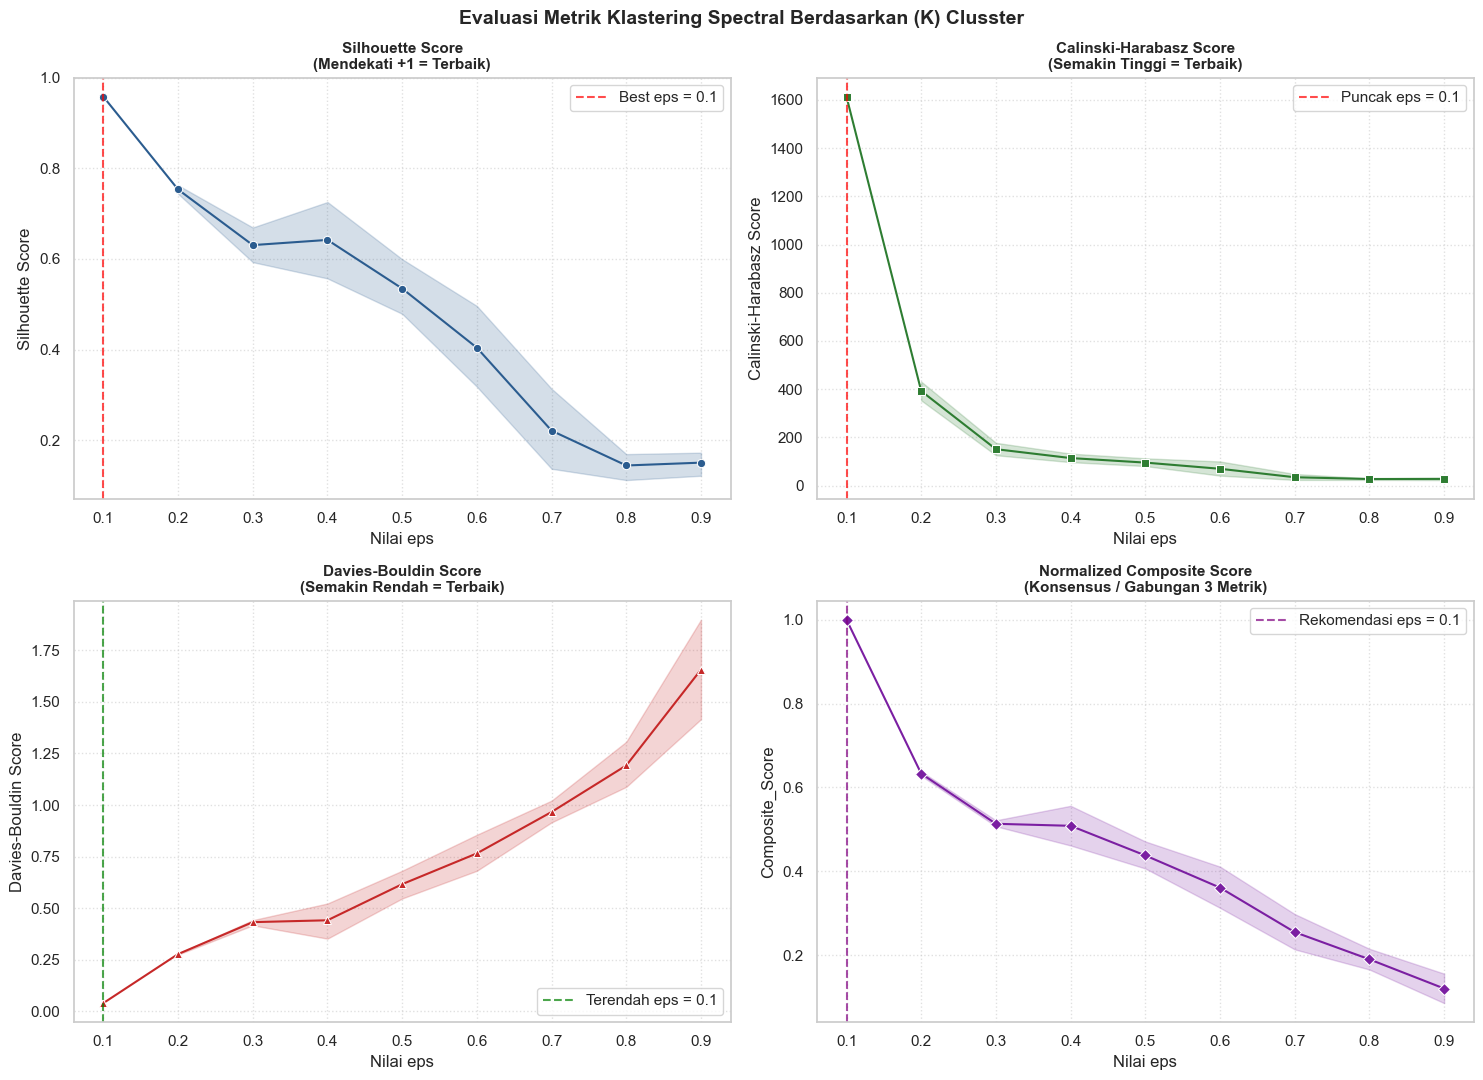

,Clusters Found,eps,minPTS,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Composite_Score
0,3,0.1,2,0.958291,1613.385516,0.040348,1.000000
1,19,0.2,2,0.743920,431.076243,0.275195,0.638052
2,7,0.2,3,0.762820,353.234392,0.280477,0.627987
3,37,0.3,2,0.592918,177.298997,0.417082,0.507424
4,14,0.3,3,0.629349,149.547561,0.442296,0.511180
5,4,0.3,4,0.669468,125.770237,0.438211,0.521667
6,34,0.4,2,0.482093,90.873317,0.572312,0.424437
7,18,0.4,3,0.537968,108.254373,0.555641,0.451270
8,8,0.4,4,0.611392,98.394297,0.509832,0.483420
9,4,0.4,5,0.698530,95.625493,0.378924,0.535304


In [ ]:
eps_range = np.arange(0.1, 1.0, 0.1) 
min_val = np.arange(2, 10, 1)

eps_values = []
min_pts_values = []        
sil_scores = []
ch_scores = []
db_scores = []
n_clusters_found = []

for eps in eps_range:
    for minPTS in min_val:
        dbscan = DBSCAN(eps=eps, min_samples=minPTS)
        labels = dbscan.fit_predict(X_cleaned)
        core_mask = labels != -1 # Filter titik noise (-1) untuk perhitungan metrik evaluasi
        unique_labels = set(labels[core_mask])
        
        if len(unique_labels) >= 2:  # Metrik hanya bisa dihitung jika terdapat minimal 2 cluster non-noise
            X_valid = X_cleaned[core_mask]
            labels_valid = labels[core_mask]
                
            eps_values.append(round(eps, 2))
            min_pts_values.append(minPTS)
            sil_scores.append(silhouette_score(X_valid, labels_valid))
            ch_scores.append(calinski_harabasz_score(X_valid, labels_valid))
            db_scores.append(davies_bouldin_score(X_valid, labels_valid))
            n_clusters_found.append(len(unique_labels))
   
df_scores = pd.DataFrame({
    'Clusters Found': n_clusters_found,
    'eps': eps_values,
    'minPTS': min_pts_values,      
    'Silhouette Score': sil_scores,
    'Calinski-Harabasz Score': ch_scores,
    'Davies-Bouldin Score': db_scores
})

scaler = MinMaxScaler()
norm_sil = scaler.fit_transform(df_scores[['Silhouette Score']])
norm_ch = scaler.fit_transform(df_scores[['Calinski-Harabasz Score']])
norm_db = 1 - scaler.fit_transform(df_scores[['Davies-Bouldin Score']])
df_scores['Composite_Score'] = (norm_sil + norm_ch + norm_db) / 3

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- Plot 1: Silhouette Score ---
best_idx_sil = df_scores['Silhouette Score'].idxmax()
best_eps_sil = df_scores.loc[best_idx_sil, 'eps']
sns.lineplot(ax=axes[0, 0], x='eps', y='Silhouette Score', data=df_scores, marker='o', markersize=6, linewidth=1.5, color='#2b5c8f')
axes[0, 0].axvline(x=best_eps_sil, color='red', linestyle='--', alpha=0.7, label=f'Best eps = {best_eps_sil}')
axes[0, 0].set_title('Silhouette Score\n(Mendekati +1 = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Nilai eps')
axes[0, 0].grid(True, linestyle=':', alpha=0.6)
axes[0, 0].legend()

# --- Plot 2: Calinski-Harabasz Score ---
best_idx_ch = df_scores['Calinski-Harabasz Score'].idxmax()
best_eps_ch = df_scores.loc[best_idx_ch, 'eps']
sns.lineplot(ax=axes[0, 1], x='eps', y='Calinski-Harabasz Score', data=df_scores, marker='s', markersize=6, linewidth=1.5, color='#2e7d32')
axes[0, 1].axvline(x=best_eps_ch, color='red', linestyle='--', alpha=0.7, label=f'Puncak eps = {best_eps_ch}')
axes[0, 1].set_title('Calinski-Harabasz Score\n(Semakin Tinggi = Terbaik)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Nilai eps')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)
axes[0, 1].legend()

# --- Plot 3: Davies-Bouldin Score ---
best_idx_db = df_scores['Davies-Bouldin Score'].idxmin()
best_eps_db = df_scores.loc[best_idx_db, 'eps']
sns.lineplot(ax=axes[1, 0], x='eps', y='Davies-Bouldin Score', data=df_scores, marker='^', markersize=6, linewidth=1.5, color='#c62828')
axes[1, 0].axvline(x=best_eps_db, color='green', linestyle='--', alpha=0.7, label=f'Terendah eps = {best_eps_db}')
axes[1, 0].set_title('Davies-Bouldin Score\n(Semakin Rendah = Terbaik)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Nilai eps')
axes[1, 0].grid(True, linestyle=':', alpha=0.6)
axes[1, 0].legend()

# --- Plot 4: Normalized Composite Score ---
best_idx_comp = df_scores['Composite_Score'].idxmax()
best_eps_comp = df_scores.loc[best_idx_comp, 'eps']
sns.lineplot(ax=axes[1, 1], x='eps', y='Composite_Score', data=df_scores, marker='D', markersize=6, linewidth=1.5, color='#7b1fa2')
axes[1, 1].axvline(x=best_eps_comp, color='purple', linestyle='--', alpha=0.7, label=f'Rekomendasi eps = {best_eps_comp}')
axes[1, 1].set_title('Normalized Composite Score\n(Konsensus / Gabungan 3 Metrik)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Nilai eps')
axes[1, 1].grid(True, linestyle=':', alpha=0.6)
axes[1, 1].legend()

plt.suptitle('Evaluasi Metrik Klastering Spectral Berdasarkan (K) Clusster', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
df_scores

In [91]:
min_samples_val = 6
epsilon = 0.4
best_dbscan = DBSCAN(eps=epsilon,min_samples=min_samples_val)
df['Cluster'] = best_dbscan.fit_predict(X_cleaned)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,Male,19,15,39,-1
1,Male,21,15,81,-1
2,Female,20,16,6,-1
3,Female,23,16,77,-1
4,Female,31,17,40,-1


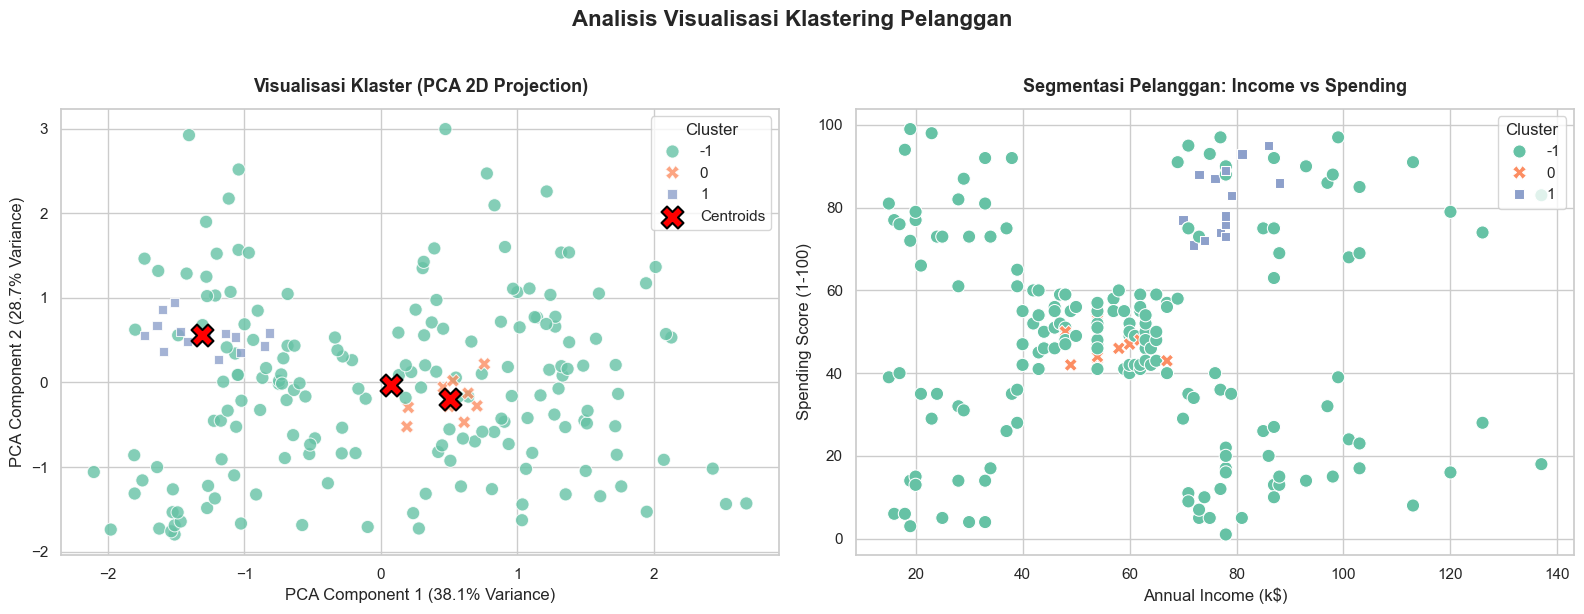

In [92]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cleaned)

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster'].values
centroids_pca = df_pca.groupby('Cluster')[['PCA1', 'PCA2']].mean().values

sns.set_theme(style="whitegrid")
palette = 'Set2'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(ax=axes[0],x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette=palette, s=90, alpha=0.8, style='Cluster')
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=250, c='red', marker='X', edgecolor='black', linewidth=1.5, label='Centroids') # Plot Centroid
axes[0].set_title('Visualisasi Klaster (PCA 2D Projection)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
axes[0].set_ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
axes[0].legend(title='Cluster', loc='upper right')

sns.scatterplot( ax=axes[1],x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df,  palette=palette, s=90, style='Cluster')
axes[1].set_title('Segmentasi Pelanggan: Income vs Spending', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].legend(title='Cluster', loc='upper right')

plt.suptitle('Analisis Visualisasi Klastering Pelanggan', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

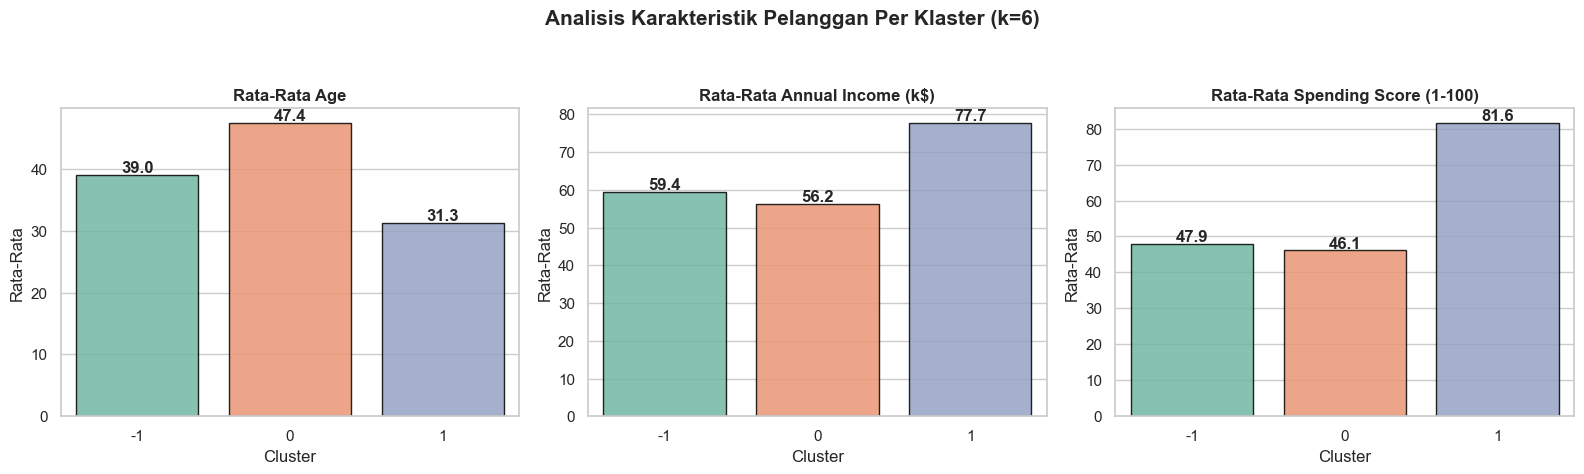

In [93]:
df_profile = df.groupby('Cluster')[num_cols].mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(num_cols):
    sns.barplot(ax=axes[i], x='Cluster', y=col, data=df_profile,hue='Cluster',legend=False,palette=palette, edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Rata-Rata {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Rata-Rata')
    for p in axes[i].patches: # Menambahkan label nilai angka di atas bar
        axes[i].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.suptitle(f'Analisis Karakteristik Pelanggan Per Klaster (k={min_samples_val})', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()